# Medidas de heterogeneidad

Índices para variables cualitativas: **Gini-Simpson**, **IQV** y **entropía de Shannon**,
calculados sobre el dataset crudo y el procesado, con proporciones simples y ponderadas (`factor_expansion`).

In [2]:
!pip install -q polars

import math
from pathlib import Path

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

## 1. Rutas de los datos

In [7]:
FUENTES = {
    "crudo": Path("/content/endireh_2021.csv"),
    "procesado": Path("/content/endireh_2021_clean.csv"),
}
for nombre, ruta in FUENTES.items():
    print(f"{nombre:10s} -> {ruta}  existe: {ruta.exists()}")

crudo      -> /content/endireh_2021.csv  existe: True
procesado  -> /content/endireh_2021_clean.csv  existe: True


## 2. Funciones de cálculo

In [14]:
COLUMNAS = [
    "nom_entidad",
    "nivel_escolaridad",
    "estado_civil_desc",
    "estrato_socioeconomico",
    "pareja_trabaja_desc",
    "dinero_propio_desc",
    "apoyo_gobierno_desc",
    "tiene_ahorros_desc",
    "propietaria_vivienda_desc",
    "sufrio_violencia_pareja",
    "nunca_tuvo_union",  # solo existe en el dataset procesado
]
COL_PESO = "factor_expansion"


def _proporciones(df, col, peso):
    """Devuelve (lista de p_i, n de filas válidas). Los nulos se excluyen."""
    cols = [col] + ([peso] if peso else [])
    sub = df.select(cols).drop_nulls()
    if peso:
        conteo = sub.group_by(col).agg(pl.col(peso).sum().alias("w"))
    else:
        conteo = sub.group_by(col).agg(pl.len().alias("w"))
    total = conteo["w"].sum()
    return (conteo["w"] / total).to_list(), sub.height


def calcular_heterogeneidad(df, columnas, peso=None):
    filas = []
    for col in columnas:
        if col not in df.columns:
            continue
        p, n = _proporciones(df, col, peso)
        k = len(p)
        suma_p2 = sum(x * x for x in p)

        gs = 1 - suma_p2
        iqv = k * (1 - suma_p2) / (k - 1) if k > 1 else 0.0
        h = 0.0 - sum(x * math.log2(x) for x in p if x > 0)
        h_max = math.log2(k) if k > 1 else 0.0
        h_norm = h / h_max if h_max > 0 else 0.0

        filas.append({
            "variable": col, "n": n, "k": k,
            "gini_simpson": gs, "gs_max": 1 - 1 / k if k > 0 else 0.0,
            "iqv": iqv,
            "shannon_H": h, "H_max": h_max, "H_norm": h_norm,
        })
    return pl.DataFrame(filas)

## 3. Cálculo (crudo y procesado, simple y ponderado)

In [9]:
resultados = []
for etiqueta, ruta in FUENTES.items():
    df = pl.read_csv(ruta)
    for peso, nombre_peso in [(None, "simple"), (COL_PESO, "ponderada")]:
        if peso is not None and peso not in df.columns:
            continue
        r = calcular_heterogeneidad(df, COLUMNAS, peso=peso).with_columns(
            pl.lit(etiqueta).alias("dataset"),
            pl.lit(nombre_peso).alias("proporciones"),
        )
        resultados.append(r)

res = pl.concat(resultados)
res_pd = res.to_pandas()

with pl.Config(tbl_cols=-1, tbl_rows=-1, tbl_width_chars=250):
    display(res.filter((pl.col("dataset") == "procesado") & (pl.col("proporciones") == "ponderada")))

variable,n,k,gini_simpson,gs_max,iqv,shannon_H,H_max,H_norm,dataset,proporciones
str,i64,i64,f64,f64,f64,f64,f64,f64,str,str
"""nom_entidad""",105753,32,0.945809,0.96875,0.976319,4.590937,5.0,0.918187,"""procesado""","""ponderada"""
"""nivel_escolaridad""",105753,6,0.673891,0.833333,0.808669,2.005634,2.584963,0.775885,"""procesado""","""ponderada"""
"""estado_civil_desc""",105753,6,0.758777,0.833333,0.910533,2.24682,2.584963,0.869189,"""procesado""","""ponderada"""
"""estrato_socioeconomico""",105753,4,0.652986,0.75,0.870649,1.741453,2.0,0.870727,"""procesado""","""ponderada"""
"""pareja_trabaja_desc""",105753,2,0.496014,0.5,0.992028,0.994242,1.0,0.994242,"""procesado""","""ponderada"""
"""dinero_propio_desc""",105753,2,0.498294,0.5,0.996588,0.997537,1.0,0.997537,"""procesado""","""ponderada"""
"""apoyo_gobierno_desc""",105753,2,0.225121,0.5,0.450242,0.555438,1.0,0.555438,"""procesado""","""ponderada"""
"""tiene_ahorros_desc""",105753,2,0.195616,0.5,0.391233,0.499561,1.0,0.499561,"""procesado""","""ponderada"""
"""propietaria_vivienda_desc""",105753,2,0.446755,0.5,0.893509,0.921758,1.0,0.921758,"""procesado""","""ponderada"""


## 4. Gráficas

El IQV y la razón H/H_max están normalizados entre 0 (una sola categoría concentra todo)
y 1 (categorías perfectamente balanceadas), por eso se pueden comparar entre variables con distinto número de categorías.

### 4.1 Crudo vs procesado (IQV, proporciones simples)

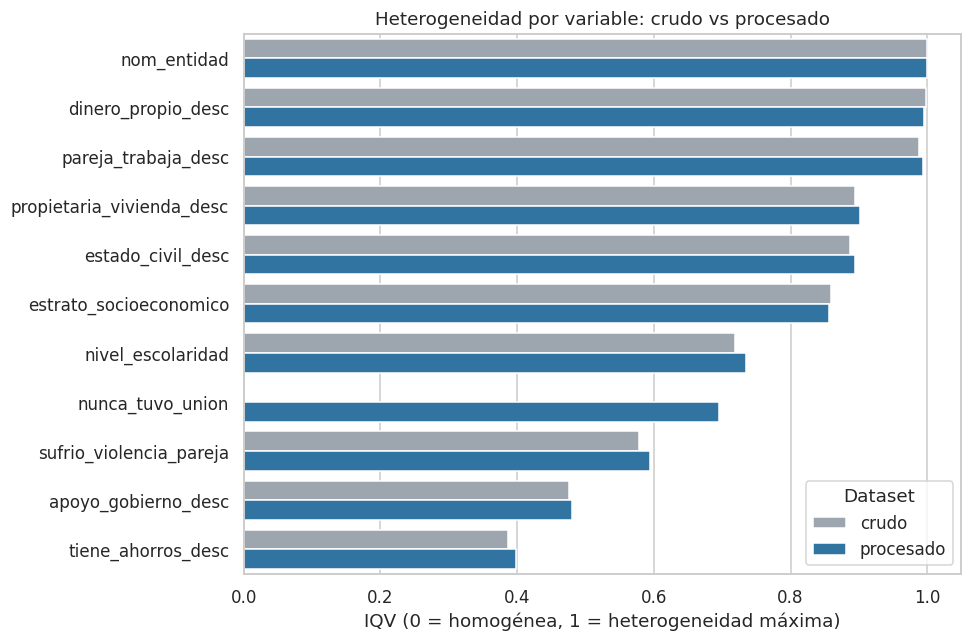

In [15]:
orden = (
    res_pd[(res_pd.dataset == "procesado") & (res_pd.proporciones == "simple")]
    .sort_values("iqv", ascending=False)["variable"].tolist()
)
datos = res_pd[res_pd.proporciones == "simple"]

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=datos, y="variable", x="iqv", hue="dataset", order=orden,
            palette=["#9aa5b1", "#1f77b4"], ax=ax)
ax.set_xlim(0, 1.05)
ax.set_xlabel("IQV (0 = homogénea, 1 = heterogeneidad máxima)")
ax.set_ylabel("")
ax.set_title("Heterogeneidad por variable: crudo vs procesado")
ax.legend(title="Dataset", loc="lower right")
plt.tight_layout()
plt.show()

### 4.2 Proporciones simples vs ponderadas (dataset procesado)

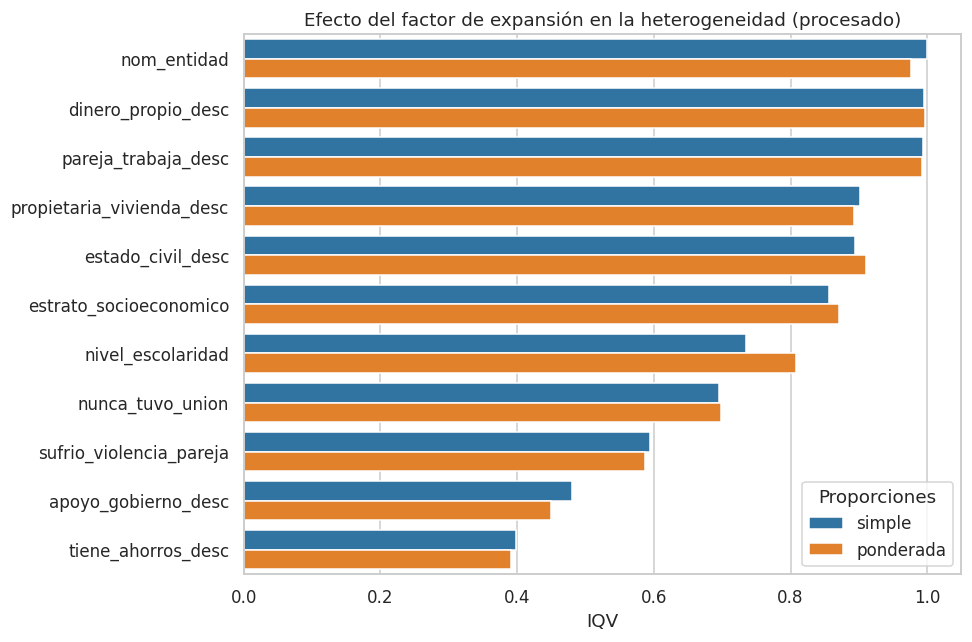

In [11]:
datos = res_pd[res_pd.dataset == "procesado"]

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=datos, y="variable", x="iqv", hue="proporciones", order=orden,
            palette=["#1f77b4", "#ff7f0e"], ax=ax)
ax.set_xlim(0, 1.05)
ax.set_xlabel("IQV")
ax.set_ylabel("")
ax.set_title("Efecto del factor de expansión en la heterogeneidad (procesado)")
ax.legend(title="Proporciones", loc="lower right")
plt.tight_layout()
plt.show()

### 4.3 Consistencia entre índices (IQV vs H/H_max)

Si los índices cuentan la misma historia, las barras deben ser parecidas. Una diferencia grande indicaría
una variable con muchas categorías raras y pocas dominantes.

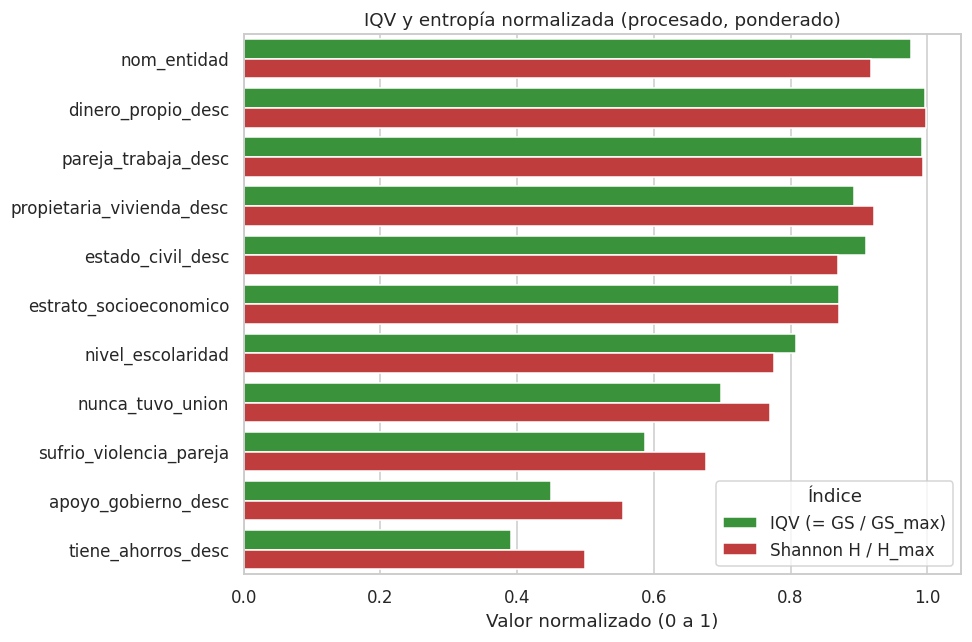

In [16]:
datos = (
    res_pd[(res_pd.dataset == "procesado") & (res_pd.proporciones == "ponderada")]
    .melt(id_vars="variable", value_vars=["iqv", "H_norm"],
          var_name="indice", value_name="valor")
)
datos["indice"] = datos["indice"].map({"iqv": "IQV (= GS / GS_max)", "H_norm": "Shannon H / H_max"})

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=datos, y="variable", x="valor", hue="indice", order=orden,
            palette=["#2ca02c", "#d62728"], ax=ax)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Valor normalizado (0 a 1)")
ax.set_ylabel("")
ax.set_title("IQV y entropía normalizada (procesado, ponderado)")
ax.legend(title="Índice", loc="lower right")
plt.tight_layout()
plt.show()

### 4.4 Mapa de calor de todos los índices (procesado, ponderado)

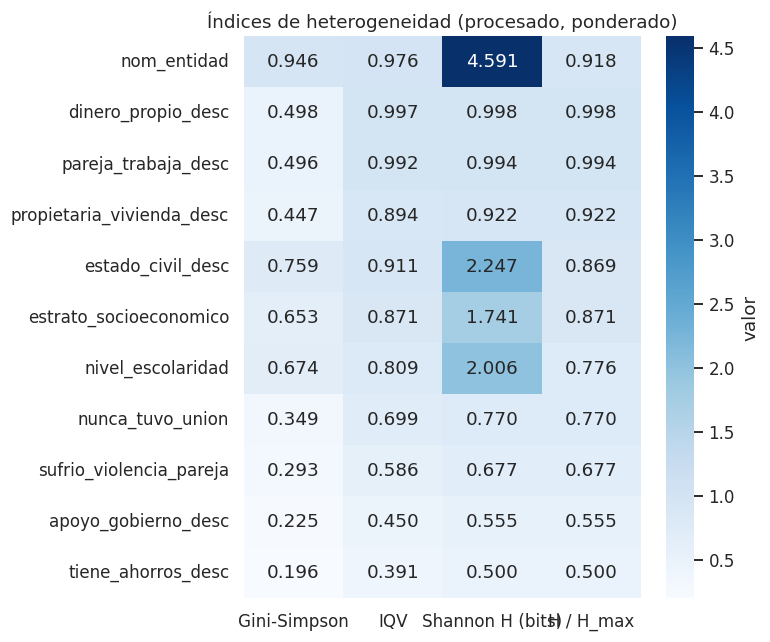

In [13]:
mapa = (
    res_pd[(res_pd.dataset == "procesado") & (res_pd.proporciones == "ponderada")]
    .set_index("variable")
    .loc[orden, ["gini_simpson", "iqv", "shannon_H", "H_norm"]]
)
mapa.columns = ["Gini-Simpson", "IQV", "Shannon H (bits)", "H / H_max"]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(mapa, annot=True, fmt=".3f", cmap="Blues", cbar_kws={"label": "valor"}, ax=ax)
ax.set_ylabel("")
ax.set_title("Índices de heterogeneidad (procesado, ponderado)")
plt.tight_layout()
plt.show()